In [1]:
import numpy as np
import pandas as pd
import os


from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from xailib.explainers.lore_explainer import LoreTabularExplainer

from xailib.models.sklearn_classifier_wrapper import sklearn_classifier_wrapper
from xailib.data_loaders.dataframe_loader import prepare_dataframe
from xailib.explainers.shap_explainer_tab import ShapXAITabularExplainer

from lore_explainer.explanation import ExplanationEncoder
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from lore_sa.dataset import TabularDataset

from plot_explanation import PlotExplanation
import matplotlib.pyplot as plt

In [2]:
path = os.getcwd()
print(path)
source_file=f'../../datasets/adult/adult.csv'
print(source_file)

/Users/eleonoracappuccio/xai-visualization_rules_fi/notebooks/experiments_dataset+anchor
../../datasets/adult/adult.csv


### Dataset handling
Lore libray has a module devoted to dataset handling. Here we use TabularDataset class to load a dataset from a csv file. A TabularDataset has a column that represent the target class (class_name) of the classification task object, and has two main attributes:

df : a pandas dataframe representing the tabular data
descriptor : a dictionary containing internal data related to the dataset. It is build when a TabularDataset is created, but it could also be edited. It is used by the next steps of LORE methodology to distinguish among numerical, categorical, ordinal and target features of the dataset.

In [3]:
dataset = TabularDataset.from_csv(source_file, class_name = "income")
dataset.df.dropna(inplace = True)
dataset.df

2024-03-07 15:58:06,096 root         INFO     ../../datasets/adult/adult.csv file imported


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [13]:
dataset.df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   education       45222 non-null  object
 3   marital-status  45222 non-null  object
 4   occupation      45222 non-null  object
 5   relationship    45222 non-null  object
 6   race            45222 non-null  object
 7   gender          45222 non-null  object
 8   capital-gain    45222 non-null  int64 
 9   capital-loss    45222 non-null  int64 
 10  hours-per-week  45222 non-null  int64 
 11  native-country  45222 non-null  object
 12  income          45222 non-null  object
dtypes: int64(4), object(9)
memory usage: 4.8+ MB


In [4]:
dataset.descriptor.keys()

dict_keys(['numeric', 'categorical', 'target'])

In [5]:
dataset.df.drop(['fnlwgt', 'educational-num'], inplace=True, axis=1)
dataset.update_descriptor()

### ONE HOT ENCODING

In [6]:
#categorical features of our dataset
dataset.descriptor['categorical'].keys()

dict_keys(['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country'])

In [7]:
from lore_sa.encoder_decoder import TabularEnc
encoder = TabularEnc(dataset.descriptor)

encoded = []
for x in dataset.df.iloc:
    
    
    encoded.append(encoder.encode(x.values))

In [8]:
encoder.dataset_descriptor

{'numeric': {'age': {'index': 0,
   'min': 17,
   'max': 90,
   'mean': 38.547941267524656,
   'std': 13.217870219055518,
   'median': 37.0,
   'q1': 28.0,
   'q3': 47.0},
  'capital-gain': {'index': 8,
   'min': 0,
   'max': 99999,
   'mean': 1101.4303436380524,
   'std': 7506.43008374525,
   'median': 0.0,
   'q1': 0.0,
   'q3': 0.0},
  'capital-loss': {'index': 9,
   'min': 0,
   'max': 4356,
   'mean': 88.595418159303,
   'std': 404.956092058965,
   'median': 0.0,
   'q1': 0.0,
   'q3': 0.0},
  'hours-per-week': {'index': 10,
   'min': 1,
   'max': 99,
   'mean': 40.93801689443191,
   'std': 12.007508230033451,
   'median': 40.0,
   'q1': 40.0,
   'q3': 45.0}},
 'categorical': {'workclass': {'index': 1,
   'distinct_values': ['Private',
    'Local-gov',
    'Self-emp-not-inc',
    'Federal-gov',
    'State-gov',
    'Self-emp-inc',
    'Without-pay'],
   'count': {'Private': 33307,
    'Local-gov': 3100,
    'Self-emp-not-inc': 3796,
    'Federal-gov': 1406,
    'State-gov': 1946,


Once we have an TabularEnc object, we can apply the decode() method to an encoded instance, in order to get the decoded instance.

In [9]:
encoder.decode(encoded[0])

array(['25', 'Private', '11th', 'Never-married', 'Machine-op-inspct',
       'Own-child', 'Black', 'Male', '0', '0', '40', 'United-States',
       '<=50K'], dtype='<U21')

In [10]:
print(encoded[0])

[25  1  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  1  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0
  0  0  0  1  0  0  0  0  1  0  0  0 40  1  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0]


### The blackbox
LORE explains the reasoning of an input machine learning model (blackbox) that classifies an input instance of the dataset. Since this is a tutorial, we will create a blackbox from scratch, in order to explain it through LORE.

We will explain a blackbox that is taking one-hot-encoded instances as input. Hence, we create an encoded version of the original dataframe

In [16]:
encoded_df = pd.DataFrame(encoded, columns = [encoder.encoded_features[i] for i in range(len(encoded[0]))])
encoded_df

,age,workclass=Private,workclass=Local-gov,workclass=Self-emp-not-inc,workclass=Federal-gov,workclass=State-gov,workclass=Self-emp-inc,workclass=Without-pay,education=11th,education=HS-grad,...,native-country=Ecuador,native-country=Yugoslavia,native-country=Hungary,native-country=Hong,native-country=Greece,native-country=Trinadad&Tobago,native-country=Outlying-US(Guam-USVI-etc),native-country=France,native-country=Holand-Netherlands,income
0,25,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,38,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,28,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,44,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,34,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
45218,40,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
45219,58,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
45220,22,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [17]:
feature_names = [c for c in encoded_df.columns if c != 'income']
class_name = dataset.class_name
test_size= 0.2
random_state= 42

X_train, X_test, Y_train, Y_test = train_test_split(encoded_df[feature_names].values, encoded_df[class_name].values,
                                                    test_size=test_size,
                                                    random_state=random_state,
                                                    stratify=encoded_df[class_name].values)

### Gradient Boosting

In [19]:
gb = GradientBoostingClassifier(n_estimators=10, learning_rate=0.95, max_depth=6, random_state=random_state)
gb.fit(X_train, Y_train)

GradientBoostingClassifier(learning_rate=0.95, max_depth=6, n_estimators=10,
                           random_state=42)

In [24]:
gb.score(X_test, Y_test)
from lore_sa.bbox import sklearn_classifier_bbox

bbox = sklearn_classifier_bbox.sklearnBBox(gb)

2024-02-26 15:46:24,432 matplotlib.pyplot DEBUG    Loaded backend module://matplotlib_inline.backend_inline version unknown.
2024-02-26 15:46:24,433 matplotlib.pyplot DEBUG    Loaded backend module://matplotlib_inline.backend_inline version unknown.
2024-02-26 15:46:24,441 matplotlib.font_manager DEBUG    findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2024-02-26 15:46:24,443 matplotlib.font_manager DEBUG    findfont: score(FontEntry(fname='/opt/anaconda3/envs/xai/lib/python3.8/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2024-02-26 15:46:24,444 matplotlib.font_manager DEBUG    findfont: score(FontEntry(fname='/opt/anaconda3/envs/xai/lib/python3.8/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-BoldOblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=700, stretch='normal', 

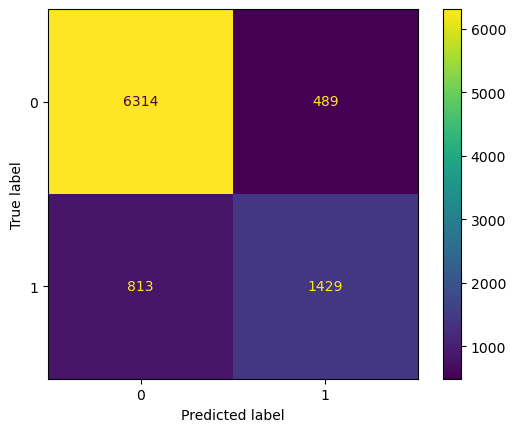

In [21]:
predictions = gb.predict(X_test)
cm = confusion_matrix(Y_test, predictions, labels=gb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gb.classes_)
disp.plot()
plt.show()

### Neighborhood generation
Given an element of the dataset, we can create an arbitrary number of synthetic instances. In this case we simulate the scenario where we only have a blackbox, a single element classified by such black box, and some limited information regarding features domains.

Here we use the RandomGenerator class to create 10000 elements starting from an element from the adult dataset.

In [22]:
# random generation

features = [c for c in encoded_df.columns if c != dataset.class_name]

x = encoded_df[features].iloc[10].values

from lore_sa.neighgen.random import RandomGenerator

gen = RandomGenerator()

neighbour = gen.generate(x,10000, dataset.descriptor, onehotencoder = encoder)

neighbour.df

2024-02-26 15:50:39,143 root         WARNING  No target class is defined


,age,workclass=Private,workclass=Local-gov,workclass=Self-emp-not-inc,workclass=Federal-gov,workclass=State-gov,workclass=Self-emp-inc,workclass=Without-pay,education=11th,education=HS-grad,...,native-country=Jamaica,native-country=Ecuador,native-country=Yugoslavia,native-country=Hungary,native-country=Hong,native-country=Greece,native-country=Trinadad&Tobago,native-country=Outlying-US(Guam-USVI-etc),native-country=France,native-country=Holand-Netherlands
0,58.450927,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,80.659782,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,27.866510,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,74.676130,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,29.596443,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,63.609955,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
9996,54.043704,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,70.446778,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
9998,60.606341,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


We now use the black box we created before to classify all the instances of the new synthetic dataset

In [25]:
neighbour.df['income'] = bbox.predict(neighbour.df[features])
neighbour.set_class_name('income')

### Surrogate model
The surrogate submodule creates a classifier and provides the methods to extract its corresponding classification rules. Once trained the surrogate, we extract a set of rules that explains why the surrogate model classifies the instance in a certain way.

In [26]:
from lore_sa.surrogate import DecisionTreeSurrogate

surrogate = DecisionTreeSurrogate()


surrogate.train(neighbour.df[features].values , neighbour.df['income'] )

DecisionTreeClassifier()

In [27]:
x = encoded_df[features].iloc[10].values

rule = surrogate.get_rule(x, neighbour, encoder)

print (rule)

premises:
capital-gain <= 7049.527099609375
capital-loss <= 2214.0028076171875
education != Doctorate
marital-status != Married-AF-spouse
marital-status != Married-civ-spouse
native-country != Guatemala
relationship != Own-child
education != Assoc-acdm
age <= 57.54843711853027 
consequence: income = <=50K


In [28]:
crules, deltas = surrogate.get_counterfactual_rules(x=x, class_name = 'income', feature_names=features, 
                                                    neighborhood_dataset = neighbour, encoder = encoder)


premises:
capital-gain <= 99992.859375
capital-gain > 23563.6904296875
age > 20.001994132995605
native-country != Mexico
education != Preschool
hours-per-week <= 76.37140274047852
education != Assoc-voc
native-country != Dominican-Republic
occupation != Farming-fishing
occupation = Craft-repair
native-country != India
capital-loss <= 2351.833251953125
capital-loss > 1688.4578247070312
education != 10th
education != 5th-6th
native-country != Nicaragua
education != 7th-8th
native-country != South
native-country != Philippines 
consequence: income = >50K [<lore_sa.rule.Expression object at 0x7f87e9091490>, <lore_sa.rule.Expression object at 0x7f87e9091280>]
premises:
capital-gain <= 21051.5009765625
capital-gain > 8305.43994140625
age > 20.54170513153076
native-country != Mexico
hours-per-week <= 75.80816268920898
marital-status != Married-civ-spouse
capital-loss <= 4345.494873046875
native-country != Cambodia
native-country != China
native-country != Hungary
native-country != Germany
nat

In [29]:
for r in crules:
    print(r)

premises:
capital-gain <= 7049.527099609375
capital-loss <= 2214.0028076171875
education != Doctorate
marital-status != Married-AF-spouse
marital-status != Married-civ-spouse
native-country != Guatemala
relationship != Own-child
education != Assoc-acdm
age <= 57.54843711853027 
consequence: income = <=50K
